<a href="https://colab.research.google.com/github/codeishitech/California-Housing-Price-predictor/blob/main/ml_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Exploratory Data** **Analysis**



In [ ]:
import pandas as pd   #for data handling
import numpy as np    #for numeric operations
import matplotlib.pyplot as plt
   #to plot graphs
# from processor import engineer_features

In [ ]:
housing_df = pd.read_csv('processed_califrnia_housing_dataset.csv')
display(housing_df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [ ]:
X = housing_df.iloc[:, :-1]
y = housing_df.iloc[:, -1]

In [ ]:
housing_df['ocean_proximity'].nunique()

5

**Handling missing data using SimpleImputer class from sklearn.impute** *and replacing the null values/ missing valus with the median instead of the mean since mean includes the outliers that might misguide the actual/true mean. hence in our case median is a more viable option to opt against the outliers.*

In [ ]:
from sklearn.impute import SimpleImputer

num_cols = X.select_dtypes(include=['int64','float64']).columns
imputer = SimpleImputer(strategy='median')
imputer.fit(X[num_cols])
X[num_cols] = imputer.transform(X[num_cols])


**Feature Engineering the dataset**

---

*Some features alone arent much powerful but when combined together give much more powerful predictions.*

####feature 1: rooms per household
####feature 2: population per household
####feature 3: bedrooms per household

In [ ]:
#ROOMS per household: FEATURE 1
X['rooms_per_household'] = X['total_rooms']/X['households']

Rooms per household.
rn we have total rooms and household but combination of the two gives the insight on the density of the house. "how crowded is the house"

In [ ]:
X['rooms_per_household'].skew()

np.float64(20.697868956710646)

In [ ]:
X['rooms_per_household_logged'] = np.log1p(X['total_rooms']/X['households'])


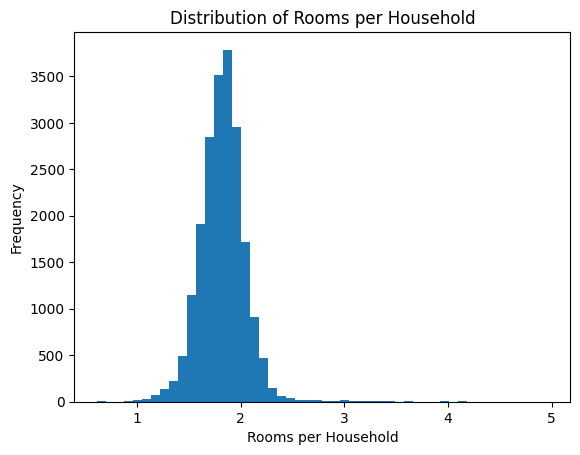

In [ ]:
import matplotlib.pyplot as plt

plt.hist(X["rooms_per_household_logged"], bins=50)
plt.xlabel("Rooms per Household")
plt.ylabel("Frequency")
plt.title("Distribution of Rooms per Household")
plt.show()


In [ ]:
#Population per household: FEATURE 2
X['population_per_household'] = X['population']/X['households']



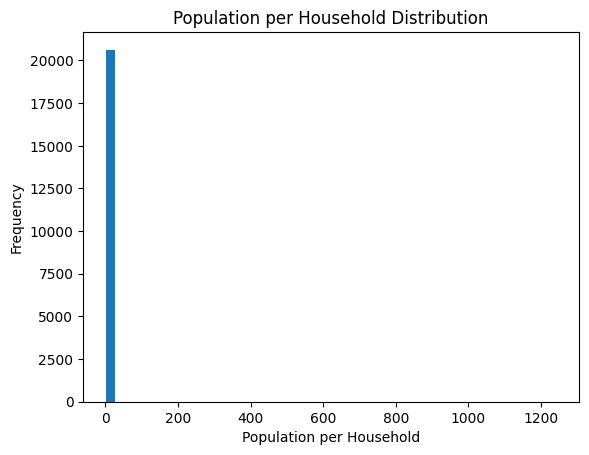

In [ ]:
plt.hist(X["population_per_household"], bins=50)
plt.xlabel("Population per Household")
plt.ylabel("Frequency")
plt.title("Population per Household Distribution")
plt.show()


In [ ]:
X['population_per_household'].skew()

np.float64(97.63956096369479)

In [ ]:
X['population_per_household_logged'] = np.log1p(X['population']/X['households'])

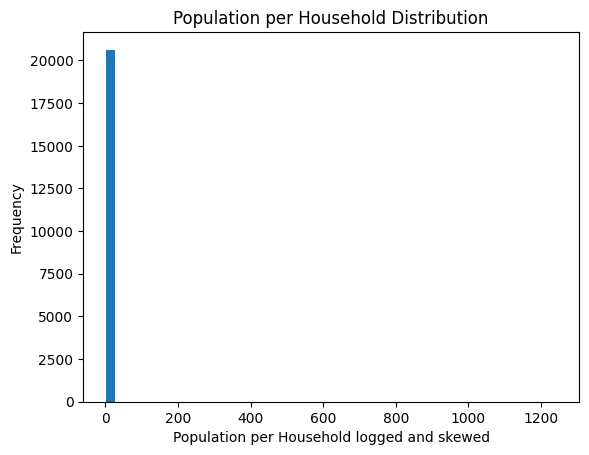

In [ ]:
plt.hist(X["population_per_household"], bins=50)
plt.xlabel("Population per Household logged and skewed")
plt.ylabel("Frequency")
plt.title("Population per Household Distribution")
plt.show()

population per houshold shows how crowded the neighbourhood is. it sheds light on the facilities availabilites and resourses.

Since data is massively skewed and shows positive skew of 97.63 which indicates the presence of heavy outliers-**Extreme right skew with long tail**.
applying Log transformation reduces variance and  to ~3.9. significantly stabilizing the distribution while preserving meaningful variability.


In [ ]:
#bedrooms per household: FEATURE 3
X['bedrooms_per_household'] = X['total_bedrooms']/X['households']


In [ ]:
cap = X["bedrooms_per_household"].quantile(0.99)
X["bedrooms_per_household_capped"] = np.clip(X["bedrooms_per_household"], None, cap)
X["bedrooms_per_household_capped_log"] = np.log(X["bedrooms_per_household_capped"])
X['bedrooms_per_household_capped_log'].skew()


np.float64(1.4836828568146014)

###Handling Extreme Skew:
#####Bedrooms per household exhibited strong skew even after log transformation due to ratio amplification.
Extreme values were capped at the 99th percentile prior to log transformation, resulting in a more stable and model-friendly distribution.

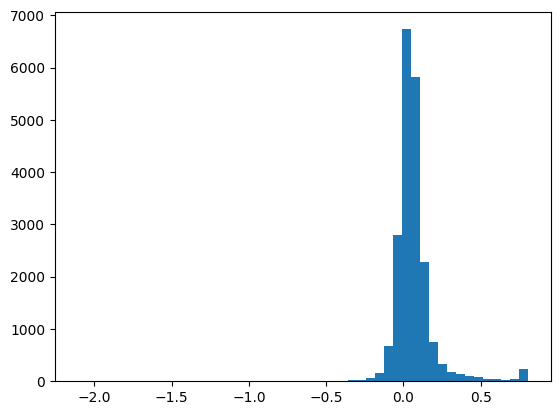

In [ ]:
plt.hist(X["bedrooms_per_household_capped_log"], bins=50)
plt.show()

*Fixing the skewed feature of total_rooms, total_bedrooms, population.

In [ ]:
X['total_rooms'].skew()
# X['total_rooms_logged'] = np.log1p(X['total_rooms'])
# plt.hist(X["total_rooms_logged"], bins=50)
plt.show()
# X['total_rooms_logged'].skew()

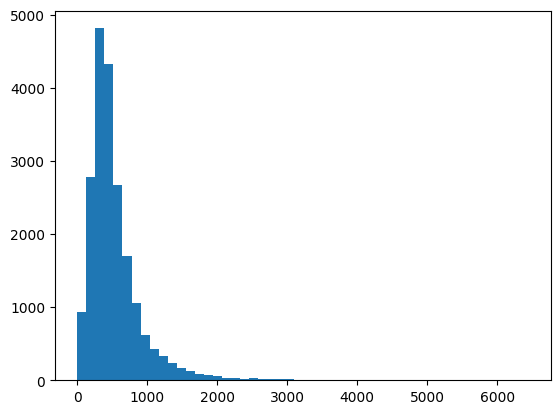

In [ ]:
X['total_bedrooms'].skew()
# X['total_bedrooms_logged'] = np.log1p(X['total_bedrooms'])
plt.hist(X["total_bedrooms"], bins=50)
plt.show()
# X['total_bedrooms_logged'].skew()

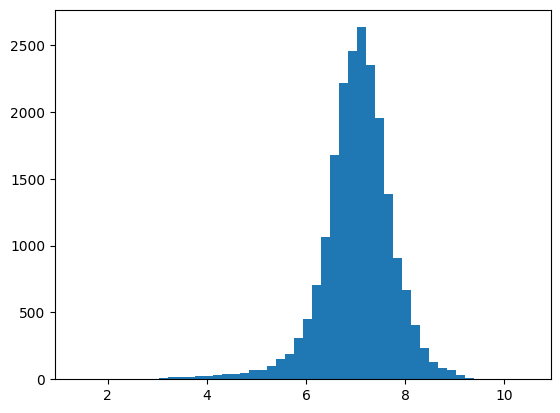

np.float64(-1.0440866961519721)

In [ ]:
X['population'].skew()
X['population_logged'] = np.log1p(X['population'])
plt.hist(X["population_logged"], bins=50)
plt.show()
X['population_logged'].skew()

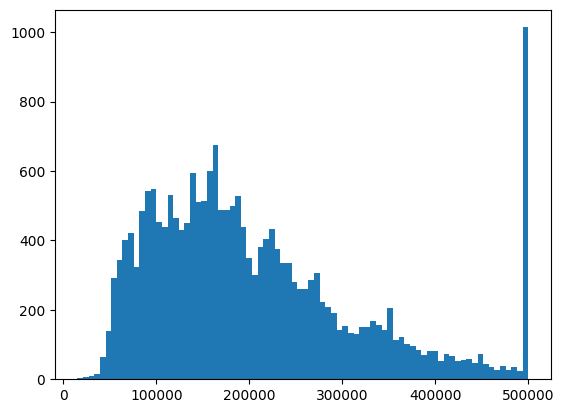

In [ ]:
plt.hist(housing_df["median_house_value"], bins=80)
plt.show()

0.9777632739098341


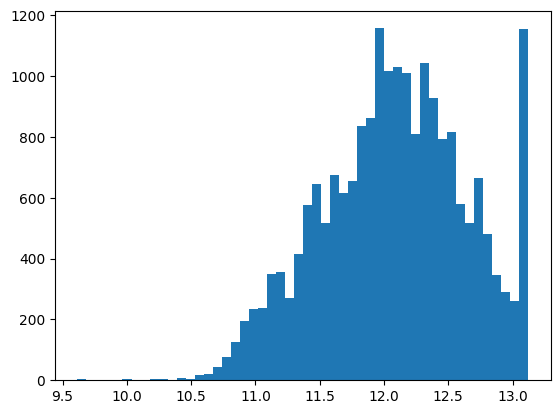

-0.17317539032496318


In [ ]:
print(housing_df['median_house_value'].skew())
housing_df['median_house_value_logged'] = np.log(housing_df['median_house_value'])
plt.hist(housing_df["median_house_value_logged"], bins=50)
plt.show()
print(housing_df['median_house_value_logged'].skew())

In [ ]:
selected_features = ["longitude",
    "latitude",
    "housing_median_age",
    "median_income",
    "households",
    "total_rooms",
    "total_bedrooms",
    "population",
    "ocean_proximity"]
X = X[selected_features]
Y = housing_df["median_house_value"]

In [ ]:
X.head()

,longitude,latitude,housing_median_age,median_income,households,total_rooms,total_bedrooms,population,ocean_proximity
0,-122.23,37.88,41.0,8.3252,126.0,880.0,129.0,322.0,NEAR BAY
1,-122.22,37.86,21.0,8.3014,1138.0,7099.0,1106.0,2401.0,NEAR BAY
2,-122.24,37.85,52.0,7.2574,177.0,1467.0,190.0,496.0,NEAR BAY
3,-122.25,37.85,52.0,5.6431,219.0,1274.0,235.0,558.0,NEAR BAY
4,-122.25,37.85,52.0,3.8462,259.0,1627.0,280.0,565.0,NEAR BAY


In [ ]:
Y.head()

,median_house_value
0,452600
1,358500
2,352100
3,341300
4,342200


In [ ]:
from sklearn.preprocessing import FunctionTransformer
def engineer_features(X):
  X = X.copy()
  X['bedrooms_per_household'] = X['total_bedrooms']/X['households']
  X['population_per_household_logged'] = np.log1p(X['population']/X['households'])
  X['rooms_per_household_logged'] = np.log1p(X['total_rooms']/X['households'])
  cap = X["bedrooms_per_household"].quantile(0.99)
  X["bedrooms_per_household_capped"] = np.clip(X["bedrooms_per_household"], None, cap)
  X["bedrooms_per_household_capped_log"] = np.log(X["bedrooms_per_household_capped"])

  X['total_rooms_logged'] = np.log1p(X['total_rooms'])
  X['total_bedrooms_logged'] = np.log1p(X['total_bedrooms'])
  X['population_logged'] = np.log1p(X['population'])

  return X


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["ocean_proximity"]

num_cols = [
    "longitude",
    "latitude",
    "housing_median_age",
    "median_income",
    "households",
    "total_rooms_logged",
    "total_bedrooms_logged",
    "population_logged",
    "rooms_per_household_logged",
    "population_per_household_logged",
    "bedrooms_per_household_capped_log"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(), cat_cols),
        ("num", "passthrough", num_cols)
    ]
)

In [ ]:
# Calculate the 'bedrooms_per_household' if you haven't already
# (Ensure you are using the training data to avoid leakage)
temp_bedrooms_per_h = X_train['total_bedrooms'] / X_train['households']

# Find the 99th percentile value
cap_value = temp_bedrooms_per_h.quantile(0.99)

print(f"Your 99th percentile cap is: {cap_value}")

Your 99th percentile cap is: 2.2016713615023464


#Random Forest Regression
an ensemble machine learning algorithm that combines the predictions of multiple decision trees to perform regression tasks


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline

feature_engineering_step = FunctionTransformer(engineer_features)



# rf = RandomForestRegressor(random_state=42)
rf_wrapped = TransformedTargetRegressor(
    regressor=RandomForestRegressor(random_state=42),
    func=np.log1p,
    inverse_func=np.expm1
)

full_pipeline = Pipeline([
    ("engineering", feature_engineering_step),
    ("preprocessing", preprocessor),
    ("model", rf_wrapped)
])

param_dist = {
    "model__regressor__n_estimators": [200, 300, 400],  #In Scikit-Learn pipelines, you use double underscores __ to navigate levels.
    "model__regressor__max_depth": [10, 20, 30, None],
    "model__regressor__min_samples_split": [2, 5, 10],
    "model__regressor__min_samples_leaf": [1, 2, 4],
    "model__regressor__max_features": ["sqrt", "log2"]
   #model__ gets you into the TransformedTargetRegressor.
  #regressor__ gets you into the actual RandomForestRegressor sitting inside it
}

search = RandomizedSearchCV(
    estimator=full_pipeline,
    param_distributions=param_dist,
    n_iter=10, #8 random combos are tried
    cv=5,   #3 cross validation
    scoring='neg_mean_absolute_error', #RMSE: Penalizes large errors heavily. One luxury house price that the model gets very wrong will ruin your entire score.
      # MAE: Tells you the "average" amount your prediction is off by (e.g., "On average, our predictions are off by $15,000"). This is often easier to explain to others.
    random_state=42,
    n_jobs=1
)


In [ ]:

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=0
)

search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('engineering',
                                              FunctionTransformer(func=<function engineer_features at 0x7f31924ec4a0>)),
                                             ('preprocessing',
                                              ColumnTransformer(transformers=[('cat',
                                                                               OneHotEncoder(),
                                                                               ['ocean_proximity']),
                                                                              ('num',
                                                                               'passthrough',
                                                                               ['longitude',
                                                                                'latitude',
                                                                                'housing_median_age',
                                                                                'median_income',
                                                                                'households',
                                                                                'total_rooms_logged',
                                                                                'tota...
                                                                         regressor=RandomForestRegressor(random_state=42)))]),
                   n_jobs=1,
                   param_distributions={'model__regressor__max_depth': [10, 20,
                                                                        30,
                                                                        None],
                                        'model__regressor__max_features': ['sqrt',
                                                                           'log2'],
                                        'model__regressor__min_samples_leaf': [1,
                                                                               2,
                                                                               4],
                                        'model__regressor__min_samples_split': [2,
                                                                                5,
                                                                                10],
                                        'model__regressor__n_estimators': [200,
                                                                           300,
                                                                           400]},
                   random_state=42, scoring='neg_mean_absolute_error')

In [ ]:
best_pipeline = search.best_estimator_
y_pred = best_pipeline.predict(X_test)
print(y_pred)

[139250.0480542  249398.62634613 144869.16368528 ... 133340.98795375
 233642.57132912 173268.96603042]


In [ ]:
# from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# import numpy as np

# # Predict on test set
# y_pred = best_pipeline.predict(X_test)

# # R2 Score
# r2 = r2_score(y_test, y_pred)

# # RMSE
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# # MAE
# mae = mean_absolute_error(y_test, y_pred)

# print(" Model Performance:")
# print("R2 Score:", round(r2, 4))
# print("RMSE:", round(rmse, 2))
# print("MAE:", round(mae, 2))

Random Forest reduced RMSE by ~18k compared to linear regression, indicating nonlinear relationships between engineered household features and housing prices.

##Gradient Boosting
---
Sequentially built trees that learn from previous errors to improve prediction.

In [ ]:
# from sklearn.ensemble import GradientBoostingRegressor

# gbr = GradientBoostingRegressor(
#     n_estimators=300,
#     learning_rate=0.05,
#     max_depth=3,
#     random_state=42
# )

# gbr.fit(X_train, y_train)

# y_pred_gbr = gbr.predict(X_test)

In [ ]:
# from sklearn.metrics import r2_score, mean_squared_error
# import numpy as np

# print("R2:", r2_score(y_test, y_pred_gbr))
# print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gbr)))

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
# 1. Mean Absolute Error (MAE): The average dollar amount you are off by
mae = mean_absolute_error(y_test, y_pred)
# 2. Root Mean Squared Error (RMSE): Penalizes larger errors more heavily
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# 3. R-squared Score: Percentage of variance explained (0 to 1)
r2 = r2_score(y_test, y_pred)
print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"Root Mean Squared Error: ${rmse:,.2f}")
print(f"R-squared Score: {r2:.4f}")

Mean Absolute Error: $32,181.60
Root Mean Squared Error: $49,707.28
R-squared Score: 0.8105


#Conclusion insight of feature engineering:
Feature engineering significantly improved linear and tree-based baseline models.
Random Forest performance slightly decreased after transformations, indicating that raw ratio features retained useful nonlinear signal.
Final model selection depends on the trade-off between interpretability and predictive accuracy.

####Random forest's r2 score dropped to 0.815 after feature engineering and rmse as 49k while the linear regression and decision tree regression r2 score increased from 0.612 to 0.65. this clearly shows that:
**One feature set rarely serves all models equally well.**
Although feature engineering improved linear regression performance, Random Forest achieved the lowest RMSE using raw ratio features. This indicates the presence of nonlinear relationships that tree-based models capture more effectively.

#Importing the model

In [ ]:
import pickle
with open("model_improved_2.pkl", "wb") as f:
    pickle.dump(best_pipeline, f)